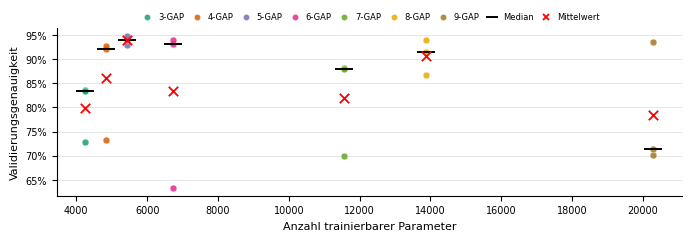

PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/abb_4_2_fmid_parameter_accuracy.pdf')

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# Rekonstruiert aus den TensorBoard-Accuracy_val-Maxima der f_mid-ft-Laeufe
params = [4254, 4838, 5422, 6730, 11554, 13874, 20290]

runs = [
    [0.7276, 0.8364, 0.8349],  # 3-GAP
    [0.9209, 0.9272, 0.7335],  # 4-GAP
    [0.9297, 0.9391, 0.9481],  # 5-GAP
    [0.9320, 0.6329, 0.9393],  # 6-GAP
    [0.8820, 0.7002, 0.8787],  # 7-GAP
    [0.8669, 0.9406, 0.9139],  # 8-GAP
    [0.7016, 0.9362, 0.7133],  # 9-GAP
]

model_names = [
    "3-GAP",
    "4-GAP",
    "5-GAP",
    "6-GAP",
    "7-GAP",
    "8-GAP",
    "9-GAP",
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a",
    "#66a61e",
    "#e6ab02",
    "#a6761d",
]

palette = dict(zip(model_names, colors))

# Long-format DataFrame für Seaborn
rows = []
for model, param_count, values in zip(model_names, params, runs):
    for value in values:
        rows.append({
            "architecture": model,
            "params": param_count,
            "accuracy": value,
        })

plot_data = pd.DataFrame(rows)

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
})

fig, ax = plt.subplots(
    figsize=(6.8, 2.3),
    constrained_layout=True,
)

# Boxplots
sns.boxplot(
    data=plot_data,
    x="architecture",
    y="accuracy",
    hue="architecture",
    order=model_names,
    hue_order=model_names,
    palette=palette,
    width=0.55,
    showfliers=False,
    saturation=1,
    legend=False,
    medianprops={"color": "0.25", "linewidth": 1.0},
    whiskerprops={"color": "0.45", "linewidth": 0.9},
    capprops={"color": "0.45", "linewidth": 0.9},
    ax=ax,
)

# Boxen transparent machen
for patch, model in zip(ax.patches, model_names):
    patch.set_facecolor(palette[model])
    patch.set_alpha(0.25)
    patch.set_edgecolor("0.35")
    patch.set_linewidth(0.9)

# Einzelne Trainingsläufe
np.random.seed(42)

sns.stripplot(
    data=plot_data,
    x="architecture",
    y="accuracy",
    hue="architecture",
    order=model_names,
    hue_order=model_names,
    palette=palette,
    jitter=0.045,
    size=3.5,
    legend=False,
    edgecolor="white",
    linewidth=0.3,
    alpha=0.9,
    zorder=3,
    ax=ax,
)

# Mittelwerte als rote Kreuze
means = [np.mean(values) for values in runs]

ax.scatter(
    range(len(model_names)),
    means,
    color="red",
    marker="x",
    s=28,
    linewidth=1.0,
    zorder=4,
    label="Mittelwert",
)

# Architektur + Parameterzahl auf der x-Achse
tick_labels = [
    f"{model}\n{param:,}".replace(",", ".")
    for model, param in zip(model_names, params)
]

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(tick_labels)

ax.set_xlabel("Architektur und Anzahl trainierbarer Parameter", labelpad=2)
ax.set_ylabel("Validierungsgenauigkeit", labelpad=2)

ax.yaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(xmax=1.0, decimals=0)
)

ax.grid(
    axis="y",
    color="0.90",
    linewidth=0.7,
    linestyle="-",
)
ax.grid(axis="x", visible=False)

sns.despine(ax=ax)

ax.legend(
    loc="upper right",
    frameon=False,
)

out_dir = Path.cwd()
if out_dir.name != "plot":
    out_dir = Path("WP2-1/single_pulse_classifier_training/plot")

pdf_path = out_dir / "abb_4_2_fmid_parameter_accuracy_boxplot.pdf"
fig.savefig(pdf_path)

plt.show()

pdf_path